# Climate change risk

Country-level vulnerability to climate change from the **[ND-GAIN Country Index](https://gain.nd.edu/our-work/country-index/)** (Notre Dame Global Adaptation Initiative). We use the composite *Vulnerability* score, which aggregates exposure, sensitivity, and adaptive capacity across six sectors (food, water, health, ecosystems, human habitat, infrastructure) into a `[0, 1]` value — higher = more vulnerable.

`DATASETS.md` originally listed [XDI's Gross Domestic Climate Risk](https://xdi.systems/news/2024-xdi-gross-domestic-climate-risk-report) here, but XDI only publishes the summary online and gates the full dataset behind an email request to `media@xdi.systems`. ND-GAIN publishes a downloadable yearly CSV and matches the intent — a Tier C country-level climate-risk layer.

We take the latest available year, rasterize by joining ND-GAIN ISO3 codes to Natural Earth country polygons, sign-invert to the atlas convention (higher = safer), and mask ocean cells using `is_land` from `grid.nc`. Because ND-GAIN reports at ADM0, values are flat inside each country border by construction (🔴 Tier C in `DATASETS.md`).

In [1]:
import zipfile

import httpx
import numpy as np
import pandas as pd
import xarray as xr

from common import RAW_DIR, load_country_mask, load_grid, plot_map, save_variable

VARIABLE = 'climate_vulnerability'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

### 1a. ND-GAIN Country Index

The 2026 release bundles every ND-GAIN indicator, sector score, and composite (Vulnerability / Readiness / GAIN) into one zip covering data through 2024. `gain.nd.edu` rejects `httpx`'s default User-Agent, so we spoof a browser one.

In [2]:
NDGAIN_URL = 'https://gain.nd.edu/assets/647440/ndgain_countryindex_2026.zip'
ndgain_zip = variable_raw / 'ndgain_countryindex_2026.zip'

if not ndgain_zip.exists():
    print(f'downloading {NDGAIN_URL}')
    r = httpx.get(NDGAIN_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ndgain_zip.write_bytes(r.content)

print(f'{ndgain_zip.name}: {ndgain_zip.stat().st_size / 1024**2:.1f} MB')

ndgain_countryindex_2026.zip: 4.7 MB


## 2. Parse ND-GAIN vulnerability

`vulnerability.csv` has one row per country and one column per year (1995 → latest). Take the latest available year, keep `ISO3` + score, drop countries with no value. Values are already in `[0, 1]` — the atlas scoring pipeline normalises again at the top level.

In [3]:
CSV_IN_ZIP = 'ND-GAIN Country Index 2026 Release Data/vulnerability/vulnerability.csv'

with zipfile.ZipFile(ndgain_zip) as z, z.open(CSV_IN_ZIP) as f:
    vulnerability_df = pd.read_csv(f)

year_cols = [c for c in vulnerability_df.columns if c.isdigit()]
latest_year = max(year_cols, key=int)

scores = (
    vulnerability_df[['ISO3', 'Name', latest_year]]
    .rename(columns={latest_year: 'vulnerability'})
    .dropna(subset=['vulnerability'])
    .set_index('ISO3')
)

print(f'{len(scores)} countries with vulnerability in {latest_year} '
      f'(range [{scores["vulnerability"].min():.3f}, {scores["vulnerability"].max():.3f}])')
scores.head()

190 countries with vulnerability in 2024 (range [0.263, 0.655])


,Name,vulnerability
ISO3,,
AFG,Afghanistan,0.611631
ALB,Albania,0.416323
DZA,Algeria,0.429884
AND,Andorra,0.350781
AGO,Angola,0.527907


## 3. Rasterize onto the 0.5° grid

Load the cached admin_0 country mask from `03_region_mask.ipynb` and join ND-GAIN vulnerability onto it by ISO3. Sign-invert so higher = safer (atlas convention) and mask ocean cells.

In [4]:
grid = load_grid()
iso_per_cell = load_country_mask()

lookup_flat = (
    pd.Series(iso_per_cell.values.ravel())
    .map(scores['vulnerability'])
    .to_numpy(dtype='float32')
)
raster = lookup_flat.reshape(iso_per_cell.shape)

# Higher vulnerability = more risk; invert so higher = safer, then mask ocean.
values = (
    xr.DataArray(-raster, coords=iso_per_cell.coords, dims=iso_per_cell.dims, name=VARIABLE)
    .where(grid.is_land == 1)
)
values

<xarray.DataArray 'climate_vulnerability' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

## 4. Plot


<Axes: title={'center': 'climate_vulnerability'}, xlabel='longitude', ylabel='latitude'>

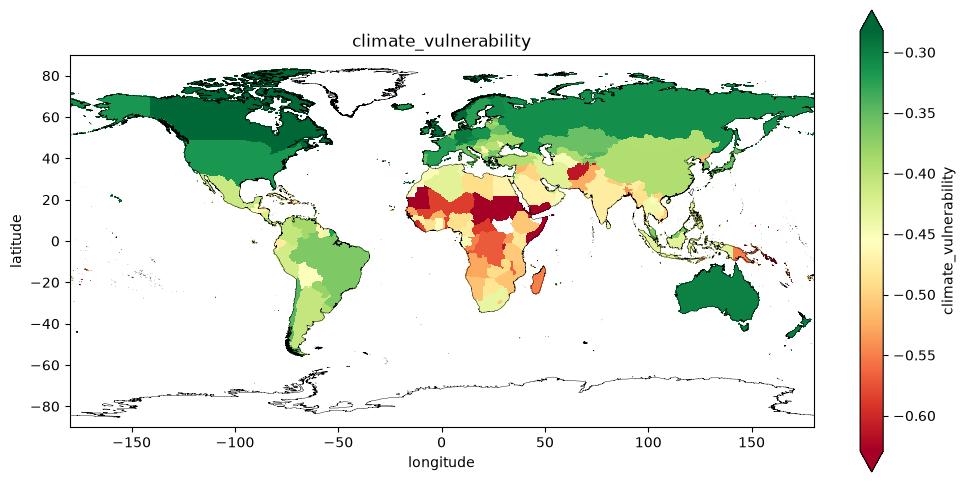

In [5]:
plot_map(values, cmap='RdYlGn', robust=True)

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/climate_vulnerability.nc
